# Task 1 : Data Preparation

In [2]:
import zipfile
import os

zip_file_name = 'sampled_images.zip'
extract_path = './'

print("Extracting zip file...")
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete!")

img_folders = [f for f in os.listdir(extract_path) if f.startswith('sampled_images')]
img_folder = os.path.join(extract_path, img_folders[0]) if img_folders else os.path.join(extract_path, 'sample_images')
print(f"Images directory found at: {img_folder}")

Extracting zip file...
Extraction complete!
Images directory found at: ./sampled_images


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

csv_path = 'data.csv'
df = pd.read_csv(csv_path)

label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['AQI_Class'])
print(f"Classes found: {label_encoder.classes_}")

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['Label']
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['Label']
)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

Classes found: ['a_Good' 'b_Moderate' 'c_Unhealthy_for_Sensitive_Groups' 'd_Unhealthy'
 'e_Very_Unhealthy' 'f_Severe']
Train size: 4200 | Val size: 900 | Test size: 900


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class AQIDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, 'Filename']
        label = self.dataframe.loc[idx, 'Label']

        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')

        # Apply transforms (resizing, converting to tensor, normalization)
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label

# Define the image transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Optional but recommended for PyTorch: Standard ImageNet Normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
BATCH_SIZE = 32

# Instantiate the datasets
train_dataset = AQIDataset(train_df, img_folder, transform=data_transforms)
val_dataset = AQIDataset(val_df, img_folder, transform=data_transforms)
test_dataset = AQIDataset(test_df, img_folder, transform=data_transforms)

# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Verify the setup by fetching one batch of data
images, labels = next(iter(train_loader))
print(f"Batch image tensor shape: {images.shape} (Batch Size, Channels, Height, Width)")
print(f"Batch label tensor shape: {labels.shape}")

Batch image tensor shape: torch.Size([32, 3, 224, 224]) (Batch Size, Channels, Height, Width)
Batch label tensor shape: torch.Size([32])


## Task 2 : Basic CNN Model

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super(BasicCNN, self).__init__()
        # 1st Convolutional Layer: 3 input channels (RGB), 32 output channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)

        # 2nd Convolutional Layer: 32 input, 64 output
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # 3rd Convolutional Layer: 64 input, 128 output
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        # Max Pooling layer (halves the spatial dimensions)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        # After 3 pooling layers, the 224x224 image becomes 28x28
        # Flattened size: 128 channels * 28 width * 28 height
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)



    def forward(self, x):
        # Apply conv -> relu -> pool
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the tensor for the fully connected layers
        x = x.view(-1, 128 * 28 * 28)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
num_classes = len(label_encoder.classes_)
model_cnn = BasicCNN(num_classes=num_classes)
print(model_cnn)

BasicCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=6, bias=True)
)


In [8]:
import torch.optim as optim

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = model_cnn.to(device)
print(f"Training on device: {device}")

# Define the loss function (CrossEntropyLoss is standard for multi-class classification)
criterion = nn.CrossEntropyLoss()

# Define the optimizer (Adam is a robust default choice)
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

Training on device: cuda


In [11]:
import time

EPOCHS = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("Starting training...")
for epoch in range(EPOCHS):
    start_time = time.time()

    model_cnn.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Calculate training accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    model_cnn.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_cnn(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Time: {epoch_time:.0f}s | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Starting training...
Epoch [1/10] - Time: 13s | Train Loss: 0.0906, Train Acc: 96.98% | Val Loss: 0.4830, Val Acc: 86.33%
Epoch [2/10] - Time: 13s | Train Loss: 0.0635, Train Acc: 97.93% | Val Loss: 0.5441, Val Acc: 86.67%
Epoch [3/10] - Time: 13s | Train Loss: 0.0264, Train Acc: 99.12% | Val Loss: 0.6574, Val Acc: 85.22%
Epoch [4/10] - Time: 13s | Train Loss: 0.0708, Train Acc: 97.83% | Val Loss: 0.7473, Val Acc: 82.67%
Epoch [5/10] - Time: 13s | Train Loss: 0.0848, Train Acc: 97.17% | Val Loss: 0.7426, Val Acc: 82.78%
Epoch [6/10] - Time: 13s | Train Loss: 0.0863, Train Acc: 97.26% | Val Loss: 0.6555, Val Acc: 86.11%
Epoch [7/10] - Time: 13s | Train Loss: 0.0441, Train Acc: 98.67% | Val Loss: 0.6012, Val Acc: 86.22%
Epoch [8/10] - Time: 13s | Train Loss: 0.0164, Train Acc: 99.50% | Val Loss: 0.6807, Val Acc: 87.33%
Epoch [9/10] - Time: 13s | Train Loss: 0.0244, Train Acc: 99.19% | Val Loss: 0.9249, Val Acc: 85.44%
Epoch [10/10] - Time: 13s | Train Loss: 0.0540, Train Acc: 98.55% | Va

In [12]:
model_cnn.eval()
test_loss = 0.0
correct_test = 0
total_test = 0

print("Evaluating on Test Set...")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

final_test_loss = test_loss / len(test_loader)
final_test_acc = 100 * correct_test / total_test

print("-" * 30)
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.2f}%")
print("-" * 30)

Evaluating on Test Set...
------------------------------
Test Loss: 0.7195
Test Accuracy: 87.00%
------------------------------


## Task 3 : Pretrained CNN Model (Transfer Learning)

In [13]:
import torchvision.models as models
import torch.nn as nn

model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print("Original ResNet18 architecture summary:")
child_counter = 0
for child in model_resnet.children():
    print(f" Child {child_counter}: {child.__class__.__name__}")
    child_counter += 1

# Freezing the first 10 layers
# In ResNet18: conv1(1) + layer1(4) + layer2(4) = 9 convolutional layers + batch norms.
# This corresponds to children 0 through 5 in PyTorch's module list.
child_counter = 0
for child in model_resnet.children():
    if child_counter < 6: # Freezes conv1, bn1, relu, maxpool, layer1, layer2
        for param in child.parameters():
            param.requires_grad = False
    child_counter += 1

print("\nWeights for the first ~10 layers have been frozen.")

num_ftrs = model_resnet.fc.in_features

num_classes = len(label_encoder.classes_)
model_resnet.fc = nn.Linear(num_ftrs, num_classes)

model_resnet = model_resnet.to(device)

optimizer_resnet = optim.Adam(filter(lambda p: p.requires_grad, model_resnet.parameters()), lr=0.001)
criterion_resnet = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


Original ResNet18 architecture summary:
 Child 0: Conv2d
 Child 1: BatchNorm2d
 Child 2: ReLU
 Child 3: MaxPool2d
 Child 4: Sequential
 Child 5: Sequential
 Child 6: Sequential
 Child 7: Sequential
 Child 8: AdaptiveAvgPool2d
 Child 9: Linear

Weights for the first ~10 layers have been frozen.


In [14]:
import time

EPOCHS_RESNET = 5

resnet_train_losses, resnet_val_losses = [], []
resnet_train_accuracies, resnet_val_accuracies = [], []

print("Starting Transfer Learning Training...")
for epoch in range(EPOCHS_RESNET):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model_resnet.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = model_resnet(images)
        loss = criterion_resnet(outputs, labels)

        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # --- VALIDATION PHASE ---
    model_resnet.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            loss = criterion_resnet(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val

    resnet_train_losses.append(train_loss)
    resnet_val_losses.append(val_loss)
    resnet_train_accuracies.append(train_acc)
    resnet_val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS_RESNET}] - Time: {time.time() - start_time:.0f}s | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Starting Transfer Learning Training...
Epoch [1/5] - Time: 12s | Train Loss: 0.6754, Train Acc: 74.60% | Val Loss: 0.3615, Val Acc: 86.33%
Epoch [2/5] - Time: 12s | Train Loss: 0.3019, Train Acc: 89.38% | Val Loss: 0.4819, Val Acc: 86.33%
Epoch [3/5] - Time: 12s | Train Loss: 0.2174, Train Acc: 92.71% | Val Loss: 0.3343, Val Acc: 88.11%
Epoch [4/5] - Time: 11s | Train Loss: 0.1477, Train Acc: 94.83% | Val Loss: 0.4689, Val Acc: 85.33%
Epoch [5/5] - Time: 12s | Train Loss: 0.1058, Train Acc: 96.19% | Val Loss: 0.1651, Val Acc: 95.11%


## Task 4 : Evaluation Function

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_and_plot_confusion_matrix(model, dataloader, model_name, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    print(f"Gathering predictions for {model_name}...")
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Calculate Metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"\n--- Performance Metrics: {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return all_preds, all_labels

Evaluating Basic CNN from scratch...
Gathering predictions for Basic CNN...

--- Performance Metrics: Basic CNN ---
Accuracy:  0.8700
Precision: 0.8743
Recall:    0.8700
F1-Score:  0.8694


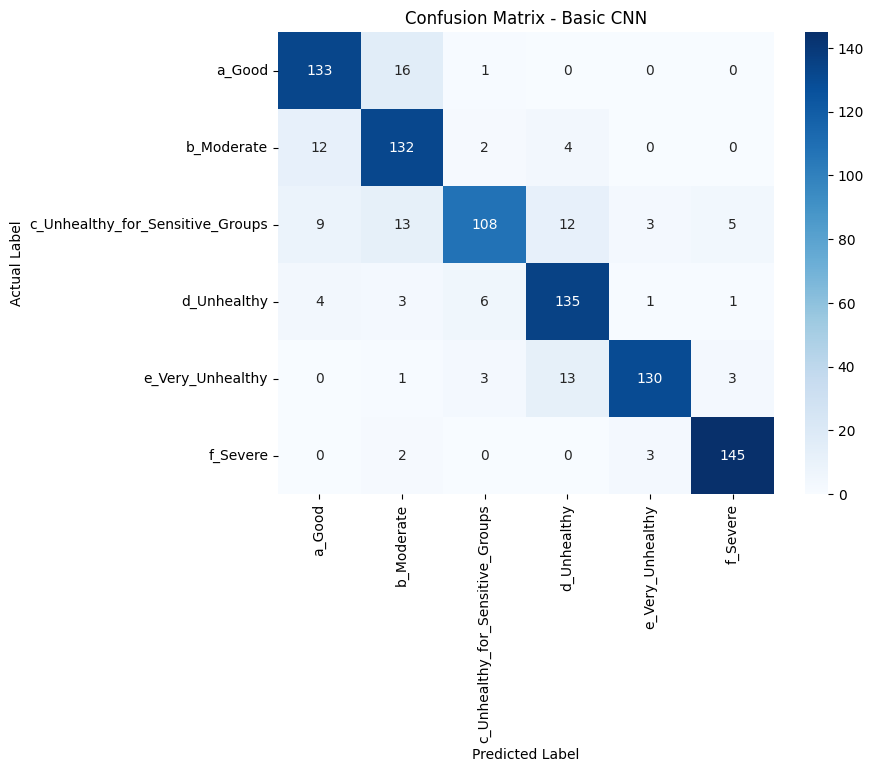



Evaluating Pretrained ResNet18...
Gathering predictions for ResNet18 (Transfer Learning)...

--- Performance Metrics: ResNet18 (Transfer Learning) ---
Accuracy:  0.9511
Precision: 0.9514
Recall:    0.9511
F1-Score:  0.9509


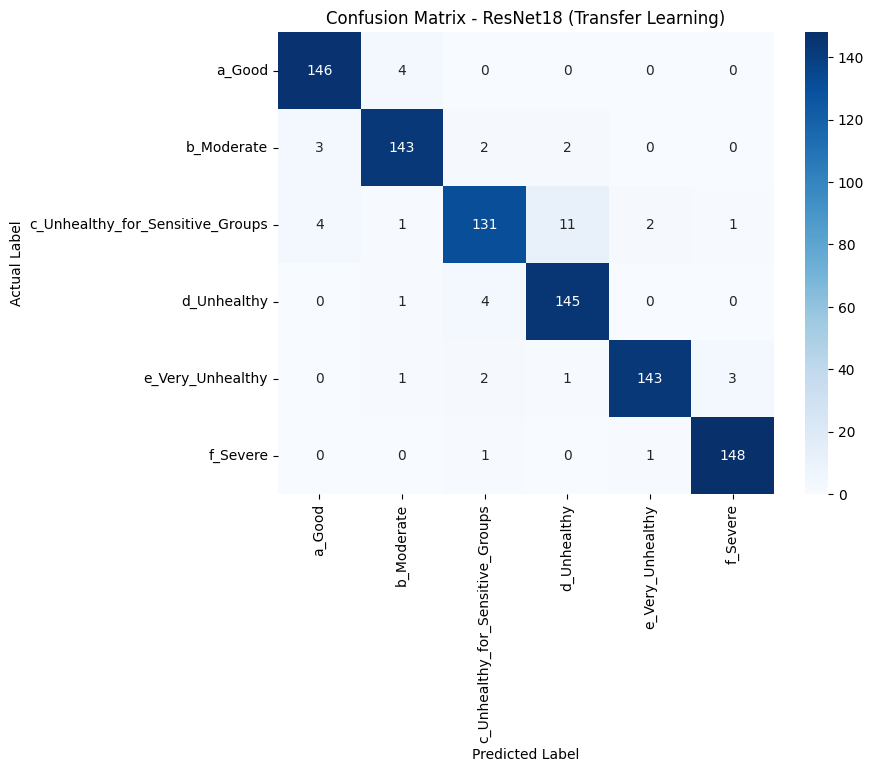

In [16]:
class_names = label_encoder.classes_

print("Evaluating Basic CNN from scratch...")
cnn_preds, cnn_labels = evaluate_and_plot_confusion_matrix(
    model=model_cnn,
    dataloader=test_loader,
    model_name="Basic CNN",
    class_names=class_names
)

print("\n" + "="*50 + "\n")

print("Evaluating Pretrained ResNet18...")
resnet_preds, resnet_labels = evaluate_and_plot_confusion_matrix(
    model=model_resnet,
    dataloader=test_loader,
    model_name="ResNet18 (Transfer Learning)",
    class_names=class_names
)

## Task 5 : Training Curves

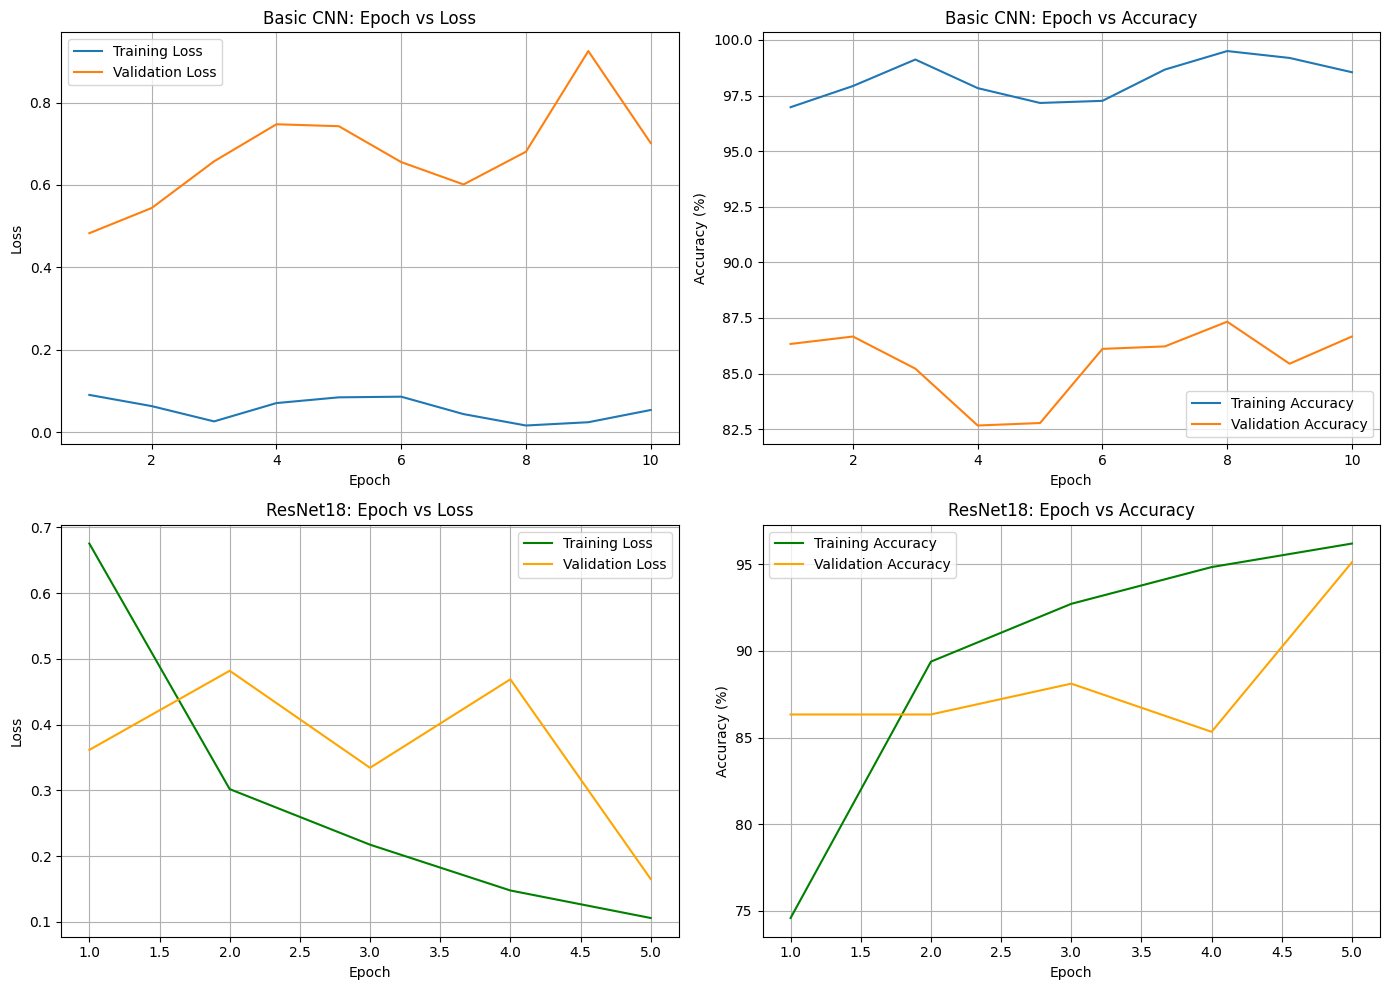

In [17]:
import matplotlib.pyplot as plt

epochs_range_cnn = range(1, len(train_losses) + 1)
epochs_range_resnet = range(1, len(resnet_train_losses) + 1)

plt.figure(figsize=(14, 10))

# 1. Basic CNN - Loss
plt.subplot(2, 2, 1)
plt.plot(epochs_range_cnn, train_losses, label='Training Loss')
plt.plot(epochs_range_cnn, val_losses, label='Validation Loss')
plt.title('Basic CNN: Epoch vs Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Basic CNN - Accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs_range_cnn, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range_cnn, val_accuracies, label='Validation Accuracy')
plt.title('Basic CNN: Epoch vs Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# 3. ResNet18 - Loss
plt.subplot(2, 2, 3)
plt.plot(epochs_range_resnet, resnet_train_losses, label='Training Loss', color='green')
plt.plot(epochs_range_resnet, resnet_val_losses, label='Validation Loss', color='orange')
plt.title('ResNet18: Epoch vs Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 4. ResNet18 - Accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs_range_resnet, resnet_train_accuracies, label='Training Accuracy', color='green')
plt.plot(epochs_range_resnet, resnet_val_accuracies, label='Validation Accuracy', color='orange')
plt.title('ResNet18: Epoch vs Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Why Pretrained Models Outperform**

- Pretrained models like ResNet18 have already been trained on massive datasets. Because of this, their early layers have already learned how to detect universal visual features such as edges, textures, gradients, and complex geometric shapes.

- When we train a basic CNN from scratch, the network starts with random weights and must figure out how to detect a basic edge before it can even begin to understand what "haze" or "smog" looks like. In a relatively small dataset like this AQI dataset, the basic CNN struggles to learn these foundational features without overfitting.

- Transfer learning bridges this gap. By freezing the early layers of ResNet18, we bypass the need to relearn basic computer vision. We only train the final layers to map those highly sophisticated, pre-learned features to our specific AQI classes. Consequently, the pretrained model converges faster, requires less data, and generally achieves significantly higher accuracy, precision, and recall on the test set.

## Task 6 : Misclassification Analysis

Hunting for misclassified images in the test set...


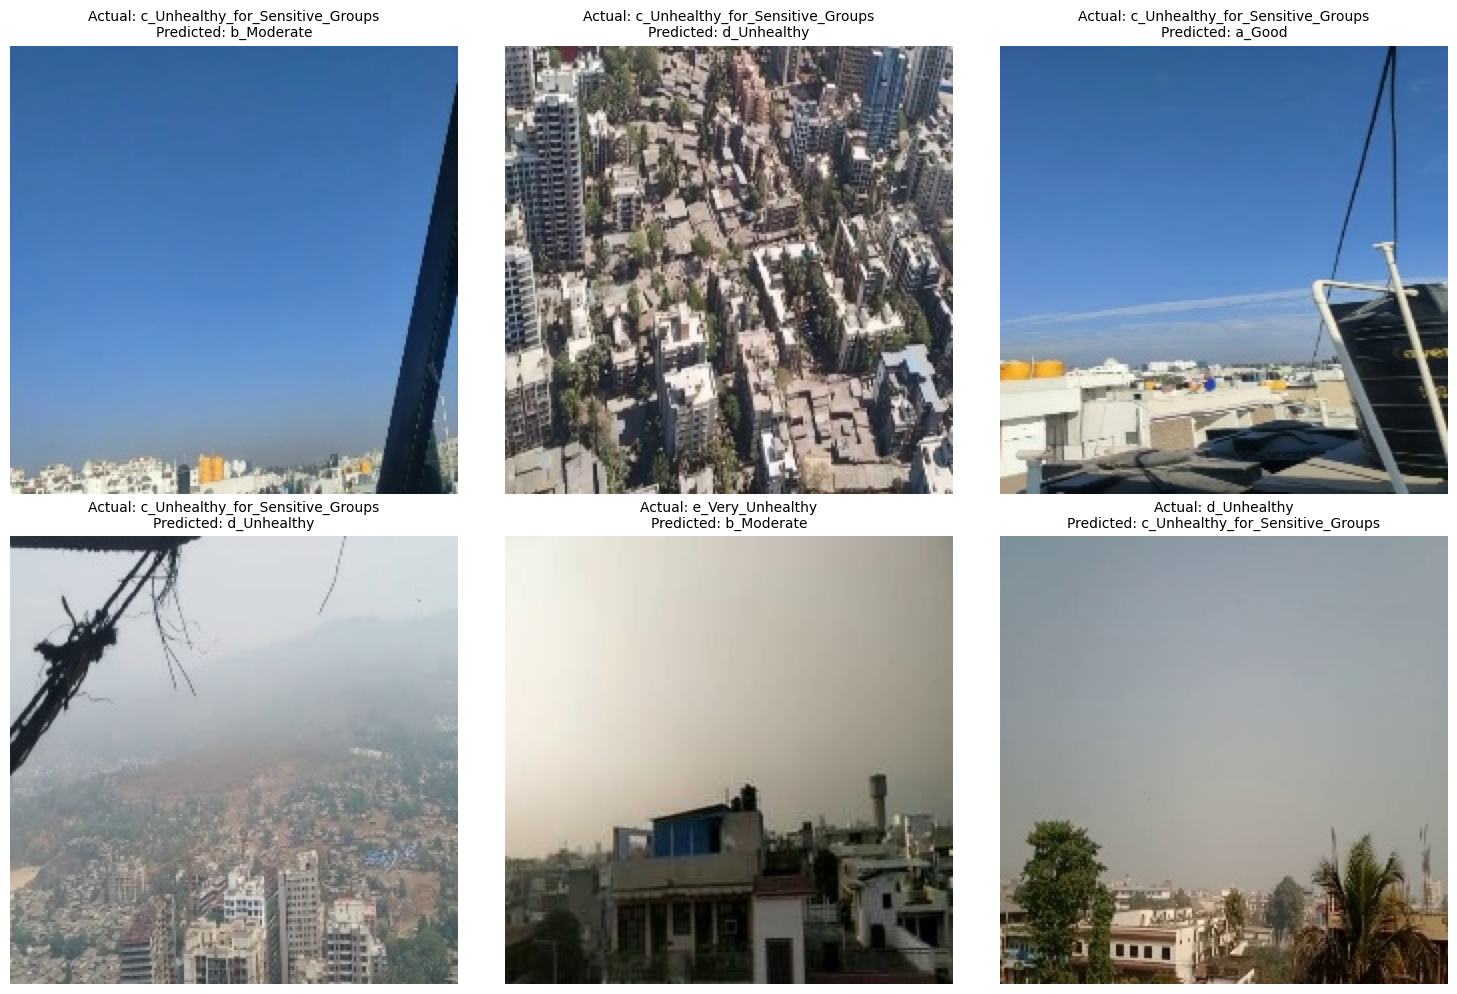

In [18]:
import numpy as np

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=10)
    plt.axis('off')

model_resnet.eval()
misclassified_images = []
misclassified_preds = []
misclassified_trues = []

print("Hunting for misclassified images in the test set...")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i])
                misclassified_preds.append(predicted[i].item())
                misclassified_trues.append(labels[i].item())

                if len(misclassified_images) == 6:
                    break
        if len(misclassified_images) == 6:
            break

fig = plt.figure(figsize=(15, 10))
for i in range(6):
    ax = fig.add_subplot(2, 3, i+1)
    true_class = label_encoder.classes_[misclassified_trues[i]]
    pred_class = label_encoder.classes_[misclassified_preds[i]]

    title = f"Actual: {true_class}\nPredicted: {pred_class}"
    imshow(misclassified_images[i], title=title)

plt.tight_layout()
plt.show()

**Possible reasons behind missclassification**

Predicting air quality purely from standard RGB images is inherently tricky because cameras capture light, not chemical composition.

- "Invisible Pollutant" (Deceptive Blue Skies): <br>
Examples: Top-left and top-right images.<br>  Reason: The model heavily associates clear, bright blue skies with "Good" or "Moderate" air quality. However, the actual label for both of these is "Unhealthy for Sensitive Groups." This happens because certain pollutants, like Ozone ($O_3$) or specific concentrations of fine particulate matter ($PM2.5$), do not always scatter enough light to create visible smog. The air looks beautifully clear to the camera lens, but it is chemically unhealthy to breathe. The model relies on visual haze, so it completely misses these invisible threats.

- Confusing Natural Weather with Pollution:<br>
Example: Bottom-left image.<br>
Reason: The model sees a thick, white/grey obstruction covering the hills and predicts "Unhealthy." The actual label is a tier lower ("Unhealthy for Sensitive Groups"). The neural network struggles to distinguish between natural weather phenomena—like morning mist, heavy fog, or low-hanging clouds—and actual industrial smog. To the model, reduced visibility automatically equals high pollution, leading to an overestimation of the AQI.

- Camera Exposure and Lighting Issues:<br>
Example: Bottom-middle image.<br>
Reason: Here, the actual AQI is "Very Unhealthy," but the model predicted "Moderate." The image appears slightly overexposed, with the sky looking like a uniform bright white or pale grey wash. Because the lighting washes out the typical dense, dirty-brown hue associated with severe smog, the model fails to recognize the severity of the pollution.

- Missing the Horizon: <br>
Example: Top-middle image.<br>
Reason: This image is a high-angle shot heavily dominated by concrete buildings and shadows, with almost no visible sky or horizon. Since the model likely learned to look at the sky to judge atmospheric scattering (haziness), the dense "concrete jungle" throws off its feature detection. The shadows and grey buildings might be misinterpreted as thick smog, causing the model to guess "Unhealthy" instead of the actual "Unhealthy for Sensitive Groups."

- Borderline Margin of Error: <br>
Example: Bottom-right image.<br>
Reason: The model predicted "Unhealthy for Sensitive Groups," but the actual label is "Unhealthy." Visually, these two adjacent categories often look identical. The transition from an AQI of 150 to 151 triggers a class change in the data, but produces absolutely no visual change in the sky. The model is making a highly educated guess on a very hazy day, but misses the exact threshold by a tiny margin.